# Lab14 112078502 楊婷婷

Requirements:  
1. Implement SARSA: Change the update rule from Q-learning to SARSA(with the same episodes) (60%)
2. Write a brief report in the notebook, including the following sections (40%):

    * Plot the Lifetime per epoch (SARSA vs. Q-learning) (10%)
    * Plot the Reward per epoch (SARSA vs. Q-learning) (10%)
    * Discussion (Analyze and discuss the differences between Q-learning and SARSA based on the game results.) (10%)
    * Upload both ipynb andmp4 files to Google Drive  
        Lab14_{student_id}.ipynb (90%, just as the description above)  
        Lab14_{student_id}.mp4 (10%, 1% per pipe)  
        Share your drive's link via eeclass  

In [ ]:
# use py=3.9.18
from ple.games.flappybird import FlappyBird
from ple import PLE
import matplotlib.pyplot as plt
import os
import numpy as np

%matplotlib inline
os.environ["SDL_VIDEODRIVER"] = "dummy"  # this line disable pop-out window
game = FlappyBird()
env = PLE(game, fps=30, display_screen=False)  # environment interface to game
env.reset_game()

# learning
import math
import copy
from collections import defaultdict
# display
from IPython.display import Image, display

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


# Common setting for both Q-learning and Sarsa

In [2]:
# return a dictionary whose key is action description and value is action index
print(game.actions)
# return a list of action index (include None)
print(env.getActionSet())

{'up': 119}
[119, None]


In [3]:
# a dictionary describe state
'''
    player y position.
    players velocity.
    next pipe distance to player
    next pipe top y position
    next pipe bottom y position
    next next pipe distance to player
    next next pipe top y position
    next next pipe bottom y position
'''
game.getGameState()

{'player_y': 256,
 'player_vel': 0,
 'next_pipe_dist_to_player': 309.0,
 'next_pipe_top_y': np.int64(144),
 'next_pipe_bottom_y': np.int64(244),
 'next_next_pipe_dist_to_player': 453.0,
 'next_next_pipe_top_y': np.int64(160),
 'next_next_pipe_bottom_y': np.int64(260)}

In [20]:
'''parameter setting'''
MIN_EXPLORING_RATE = 0.01
MIN_LEARNING_RATE = 0.5
print_every_episode = 500
show_gif_every_episode = 5000
NUM_EPISODE = 40000


In [21]:
# state related defined
num_action = len(env.getActionSet())
bucket_range_per_feature = {
  'next_next_pipe_bottom_y': 40,
  'next_next_pipe_dist_to_player': 512,
  'next_next_pipe_top_y': 40,
  'next_pipe_bottom_y': 20,
  'next_pipe_dist_to_player': 20,
  'next_pipe_top_y': 20,
  'player_vel': 4,
  'player_y': 16
}

In [ ]:
# to plot the mp4  pip install moviepy==1.0.3
import moviepy.editor as mpy

def make_anim(images, fps=60, true_image=False):
    duration = len(images) / fps

    def make_frame(t):
        try:
            x = images[int(len(images) / duration * t)]
        except:
            x = images[-1]

        if true_image:
            return x.astype(np.uint8)
        else:
            return ((x + 1) / 2 * 255).astype(np.uint8)

    clip = mpy.VideoClip(make_frame, duration=duration)
    clip.fps = fps
    return clip

# Q-learning

In [ ]:
'''Agent define'''

class Agent:

    def __init__(self,
                 bucket_range_per_feature,
                 num_action,
                 t=0,
                 discount_factor=0.99):
        self.update_parameters(t)  # init explore rate and learning rate
        self.q_table = defaultdict(lambda: np.zeros(num_action))
        self.discount_factor = discount_factor
        self.num_action = num_action

        # how to discretize each feature in a state
        # the higher each value, less time to train but with worser performance
        # e.g. if range = 2, feature with value 1 is equal to feature with value 0 bacause int(1/2) = int(0/2)
        self.bucket_range_per_feature = bucket_range_per_feature

    def select_action(self, state):
        # epsilon-greedy
        state_idx = self.get_state_idx(state)
        if np.random.rand() < self.exploring_rate:
            action = np.random.choice(self.num_action)  # Select a random action
        else:
            action = np.argmax(self.q_table[state_idx])  # Select the action with the highest q
        return action

    def update_policy(self, state, action, reward, state_prime):
        state_idx = self.get_state_idx(state)
        state_prime_idx = self.get_state_idx(state_prime)
        # Update Q_value using Q-learning update rule
        best_q = np.max(self.q_table[state_prime_idx])
        self.q_table[state_idx][action] += self.learning_rate * (
            reward + self.discount_factor * best_q - self.q_table[state_idx][action])

    def get_state_idx(self, state):
        # instead of using absolute position of pipe, use relative position
        state = copy.deepcopy(state)
        state['next_next_pipe_bottom_y'] -= state['player_y']
        state['next_next_pipe_top_y'] -= state['player_y']
        state['next_pipe_bottom_y'] -= state['player_y']
        state['next_pipe_top_y'] -= state['player_y']

        # sort to make list converted from dict ordered in alphabet order
        state_key = [k for k, v in sorted(state.items())]

        # do bucketing to decrease state space to speed up training
        state_idx = []
        for key in state_key:
            state_idx.append(int(state[key] / self.bucket_range_per_feature[key]))
        return tuple(state_idx)

    def update_parameters(self, episode):
        self.exploring_rate = max(MIN_EXPLORING_RATE,min(0.5, 0.99**((episode) / 30)))
        self.learning_rate = max(MIN_LEARNING_RATE, min(0.5, 0.99** ((episode) / 30)))

    def shutdown_explore(self):
        # make action selection greedy
        self.exploring_rate = 0

In [ ]:
# init agent of Qlearning
agent = Agent(bucket_range_per_feature, num_action)

In [ ]:
'''results of Q learning'''
reward_per_epoch = []
lifetime_per_epoch = []
exploring_rates = []
learning_rates = []

'''start training'''
for episode in range(0, NUM_EPISODE):

    # Reset the environment
    env.reset_game()
    # record frame
    frames = [env.getScreenRGB()]
    # for every 500 episodes, shutdown exploration to see performance of greedy action
    if episode % print_every_episode == 0:
        agent.shutdown_explore()
    # the initial state
    state = game.getGameState()
    # cumulate reward for this episode
    cum_reward = 0
    t = 0
    while not env.game_over():
        # select an action
        action = agent.select_action(state)
        # execute the action and get reward
        # reward = +1 when pass a pipe, -5 when die
        reward = env.act(env.getActionSet()[action])
        frames.append(env.getScreenRGB())
        # cumulate reward
        cum_reward += reward
        # observe the result
        state_prime = game.getGameState()  # get next state
        # update agent
        agent.update_policy(state, action, reward, state_prime)
        # Setting up for the next iteration
        state = state_prime
        t += 1
    # update exploring_rate and learning_rate
    agent.update_parameters(episode)

    if episode % print_every_episode == 0:
        print("Episode {} finished after {} time steps, cumulated reward: {}, exploring rate: {}, learning rate: {}".format(
            episode,
            t,
            cum_reward,
            agent.exploring_rate,
            agent.learning_rate
        ))
        reward_per_epoch.append(cum_reward)
        exploring_rates.append(agent.exploring_rate)
        learning_rates.append(agent.learning_rate)
        lifetime_per_epoch.append(t)

    # for every 5000 episode, record an animation
    if episode % show_gif_every_episode == 0:
        print("len frames:", len(frames))
        clip = make_anim(frames, fps=60, true_image=True).rotate(-90)
        display(clip.ipython_display(fps=60, autoplay=1, loop=1))

Episode 0 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
len frames: 63
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 1000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 1500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 2000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 2500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.43277903725889943, learning rate: 0.5
Episode 3000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.3660323412732292, learning rate: 0.5
Episode 3500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.30957986252419073, learning rate: 0.5
Episode 4000 finished after 65 time steps, cumulated reward: -5.0, exploring rate: 0.26183394327157605, learning rate: 0.5
Episode 4500 finished after 62 time steps, cumulated reward: -5.0, exploring rate:

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 5500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.15841112426184903, learning rate: 0.5
Episode 6000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.13397967485796172, learning rate: 0.5
Episode 6500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.11331624189077398, learning rate: 0.5
Episode 7000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.09583969128049684, learning rate: 0.5
Episode 7500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.08105851616218128, learning rate: 0.5
Episode 8000 finished after 134 time steps, cumulated reward: -3.0, exploring rate: 0.0685570138491429, learning rate: 0.5
Episode 8500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.05798359469728905, learning rate: 0.5
Episode 9000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.04904089407128572, learning rate: 0.5
Episode 9500 fin

...

Episode 25500 finished after 175 time steps, cumulated reward: -2.0, exploring rate: 0.01, learning rate: 0.5
Episode 26000 finished after 755 time steps, cumulated reward: 14.0, exploring rate: 0.01, learning rate: 0.5
Episode 26500 finished after 1336 time steps, cumulated reward: 29.0, exploring rate: 0.01, learning rate: 0.5
Episode 27000 finished after 134 time steps, cumulated reward: -3.0, exploring rate: 0.01, learning rate: 0.5
Episode 27500 finished after 1192 time steps, cumulated reward: 25.0, exploring rate: 0.01, learning rate: 0.5
Episode 28000 finished after 1038 time steps, cumulated reward: 21.0, exploring rate: 0.01, learning rate: 0.5
Episode 28500 finished after 550 time steps, cumulated reward: 8.0, exploring rate: 0.01, learning rate: 0.5
Episode 29000 finished after 1942 time steps, cumulated reward: 45.0, exploring rate: 0.01, learning rate: 0.5
Episode 29500 finished after 165 time steps, cumulated reward: -2.0, exploring rate: 0.01, learning rate: 0.5
Episode

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 30500 finished after 941 time steps, cumulated reward: 19.0, exploring rate: 0.01, learning rate: 0.5
Episode 31000 finished after 1829 time steps, cumulated reward: 42.0, exploring rate: 0.01, learning rate: 0.5
Episode 31500 finished after 1244 time steps, cumulated reward: 27.0, exploring rate: 0.01, learning rate: 0.5
Episode 32000 finished after 823 time steps, cumulated reward: 16.0, exploring rate: 0.01, learning rate: 0.5
Episode 32500 finished after 925 time steps, cumulated reward: 18.0, exploring rate: 0.01, learning rate: 0.5
Episode 33000 finished after 2584 time steps, cumulated reward: 62.0, exploring rate: 0.01, learning rate: 0.5
Episode 33500 finished after 2256 time steps, cumulated reward: 54.0, exploring rate: 0.01, learning rate: 0.5
Episode 34000 finished after 452 time steps, cumulated reward: 6.0, exploring rate: 0.01, learning rate: 0.5
Episode 34500 finished after 376 time steps, cumulated reward: 4.0, exploring rate: 0.01, learning rate: 0.5
Episode 

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 35500 finished after 3149 time steps, cumulated reward: 77.0, exploring rate: 0.01, learning rate: 0.5
Episode 36000 finished after 1305 time steps, cumulated reward: 28.0, exploring rate: 0.01, learning rate: 0.5
Episode 36500 finished after 417 time steps, cumulated reward: 5.0, exploring rate: 0.01, learning rate: 0.5
Episode 37000 finished after 3411 time steps, cumulated reward: 84.0, exploring rate: 0.01, learning rate: 0.5
Episode 37500 finished after 3452 time steps, cumulated reward: 85.0, exploring rate: 0.01, learning rate: 0.5
Episode 38000 finished after 627 time steps, cumulated reward: 10.0, exploring rate: 0.01, learning rate: 0.5
Episode 38500 finished after 438 time steps, cumulated reward: 5.0, exploring rate: 0.01, learning rate: 0.5
Episode 39000 finished after 926 time steps, cumulated reward: 18.0, exploring rate: 0.01, learning rate: 0.5
Episode 39500 finished after 360 time steps, cumulated reward: 3.0, exploring rate: 0.01, learning rate: 0.5


# SARSA

In [30]:
# inheritant from Agent(Q-learning), only define new update_policy
class Agent_Sarsa(Agent):
    def update_policy(self, state, action, reward, state_prime, action_prime):
        state_idx = self.get_state_idx(state)
        state_prime_idx = self.get_state_idx(state_prime)
        # Update Q_value using Sarsa update rule (not get best_q)
        q = self.q_table[state_prime_idx][action_prime] # change
        self.q_table[state_idx][action] += self.learning_rate * (
            reward + self.discount_factor * q - self.q_table[state_idx][action]) # change 

In [31]:
# init agent of Sarsa
agent_sarsa = Agent_Sarsa(bucket_range_per_feature, num_action)

In [32]:
'''results of sarsa'''
reward_per_epoch_sarsa = []
lifetime_per_epoch_sarsa = []
exploring_rates_sarsa = []
learning_rates_sarsa = []

'''start training'''
for episode in range(0, NUM_EPISODE):

    # Reset the environment
    env.reset_game()
    # record frame
    frames = [env.getScreenRGB()]
    # for every 500 episodes, shutdown exploration to see performance of greedy action
    if episode % print_every_episode == 0:
        agent_sarsa.shutdown_explore()
    # the initial state
    state = game.getGameState()
    # cumulate reward for this episode
    cum_reward = 0
    t = 0
    
    # initial an action (will be updated in loop ) # change
    action = agent_sarsa.select_action(state)
    while not env.game_over():
        # execute the action and get reward
        # reward = +1 when pass a pipe, -5 when die
        reward = env.act(env.getActionSet()[action])
        frames.append(env.getScreenRGB())
        # cumulate reward
        cum_reward += reward
        # observe the result
        state_prime = game.getGameState()  # get next state
        action_prime = agent_sarsa.select_action(state_prime)  # choose action(A) from S using policy derived from current Q # change

        # update agent
        agent_sarsa.update_policy(state, action, reward, state_prime, action_prime) # change

        # Setting up for the next iteration
        state = state_prime
        action = action_prime # change : A <- A'
        t += 1
    # update exploring_rate and learning_rate
    agent_sarsa.update_parameters(episode)

    if episode % print_every_episode == 0:
        print("Episode {} finished after {} time steps, cumulated reward: {}, exploring rate: {}, learning rate: {}".format(
            episode,
            t,
            cum_reward,
            agent_sarsa.exploring_rate,
            agent_sarsa.learning_rate
        ))
        reward_per_epoch_sarsa.append(cum_reward)
        exploring_rates_sarsa.append(agent_sarsa.exploring_rate)
        learning_rates_sarsa.append(agent_sarsa.learning_rate)
        lifetime_per_epoch_sarsa.append(t)

    # for every 5000 episode, record an animation
    if episode % show_gif_every_episode == 0:
        print("len frames:", len(frames))
        clip = make_anim(frames, fps=60, true_image=True).rotate(-90)
        display(clip.ipython_display(fps=60, autoplay=1, loop=1))

Episode 0 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
len frames: 63
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 1000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 1500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 2000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.5, learning rate: 0.5
Episode 2500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.43277903725889943, learning rate: 0.5
Episode 3000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.3660323412732292, learning rate: 0.5
Episode 3500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.30957986252419073, learning rate: 0.5
Episode 4000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.26183394327157605, learning rate: 0.5
Episode 4500 finished after 62 time steps, cumulated reward: -5.0, exploring rate:

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 5500 finished after 64 time steps, cumulated reward: -5.0, exploring rate: 0.15841112426184903, learning rate: 0.5
Episode 6000 finished after 98 time steps, cumulated reward: -4.0, exploring rate: 0.13397967485796172, learning rate: 0.5
Episode 6500 finished after 98 time steps, cumulated reward: -4.0, exploring rate: 0.11331624189077398, learning rate: 0.5
Episode 7000 finished after 70 time steps, cumulated reward: -4.0, exploring rate: 0.09583969128049684, learning rate: 0.5
Episode 7500 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.08105851616218128, learning rate: 0.5
Episode 8000 finished after 62 time steps, cumulated reward: -5.0, exploring rate: 0.0685570138491429, learning rate: 0.5
Episode 8500 finished after 98 time steps, cumulated reward: -4.0, exploring rate: 0.05798359469728905, learning rate: 0.5
Episode 9000 finished after 134 time steps, cumulated reward: -3.0, exploring rate: 0.04904089407128572, learning rate: 0.5
Episode 9500 fin

...

Episode 25500 finished after 550 time steps, cumulated reward: 8.0, exploring rate: 0.01, learning rate: 0.5
Episode 26000 finished after 473 time steps, cumulated reward: 6.0, exploring rate: 0.01, learning rate: 0.5
Episode 26500 finished after 92 time steps, cumulated reward: -4.0, exploring rate: 0.01, learning rate: 0.5
Episode 27000 finished after 204 time steps, cumulated reward: -1.0, exploring rate: 0.01, learning rate: 0.5
Episode 27500 finished after 98 time steps, cumulated reward: -4.0, exploring rate: 0.01, learning rate: 0.5
Episode 28000 finished after 211 time steps, cumulated reward: -1.0, exploring rate: 0.01, learning rate: 0.5
Episode 28500 finished after 1228 time steps, cumulated reward: 26.0, exploring rate: 0.01, learning rate: 0.5
Episode 29000 finished after 291 time steps, cumulated reward: 1.0, exploring rate: 0.01, learning rate: 0.5
Episode 29500 finished after 162 time steps, cumulated reward: -2.0, exploring rate: 0.01, learning rate: 0.5
Episode 30000 

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 30500 finished after 214 time steps, cumulated reward: -1.0, exploring rate: 0.01, learning rate: 0.5
Episode 31000 finished after 332 time steps, cumulated reward: 3.0, exploring rate: 0.01, learning rate: 0.5
Episode 31500 finished after 437 time steps, cumulated reward: 5.0, exploring rate: 0.01, learning rate: 0.5
Episode 32000 finished after 1458 time steps, cumulated reward: 33.0, exploring rate: 0.01, learning rate: 0.5
Episode 32500 finished after 211 time steps, cumulated reward: -1.0, exploring rate: 0.01, learning rate: 0.5
Episode 33000 finished after 3524 time steps, cumulated reward: 87.0, exploring rate: 0.01, learning rate: 0.5
Episode 33500 finished after 324 time steps, cumulated reward: 2.0, exploring rate: 0.01, learning rate: 0.5
Episode 34000 finished after 4810 time steps, cumulated reward: 121.0, exploring rate: 0.01, learning rate: 0.5
Episode 34500 finished after 1280 time steps, cumulated reward: 28.0, exploring rate: 0.01, learning rate: 0.5
Episode 

Moviepy - Done !
Moviepy - video ready __temp__.mp4


Episode 35500 finished after 437 time steps, cumulated reward: 5.0, exploring rate: 0.01, learning rate: 0.5
Episode 36000 finished after 259 time steps, cumulated reward: 1.0, exploring rate: 0.01, learning rate: 0.5
Episode 36500 finished after 2846 time steps, cumulated reward: 69.0, exploring rate: 0.01, learning rate: 0.5
Episode 37000 finished after 1306 time steps, cumulated reward: 28.0, exploring rate: 0.01, learning rate: 0.5
Episode 37500 finished after 1264 time steps, cumulated reward: 27.0, exploring rate: 0.01, learning rate: 0.5
Episode 38000 finished after 2197 time steps, cumulated reward: 52.0, exploring rate: 0.01, learning rate: 0.5
Episode 38500 finished after 889 time steps, cumulated reward: 17.0, exploring rate: 0.01, learning rate: 0.5
Episode 39000 finished after 247 time steps, cumulated reward: 0.0, exploring rate: 0.01, learning rate: 0.5
Episode 39500 finished after 678 time steps, cumulated reward: 12.0, exploring rate: 0.01, learning rate: 0.5


In [38]:
def demo():
    # Reset the environment
    env.reset_game()
    # record frame
    frames = [env.getScreenRGB()]
    # shutdown exploration to see performance of greedy action
    agent_sarsa.shutdown_explore()

    # the initial state
    state = game.getGameState()
    while not env.game_over():
        # select an action
        action = agent_sarsa.select_action(state)
        # execute the action and get reward
        reward = env.act(env.getActionSet()[action])
        frames.append(env.getScreenRGB())
        # observe the result
        state_prime = game.getGameState()  # get next state
        # Setting up for the next iteration
        state = state_prime
    clip = make_anim(frames, fps=60, true_image=True).rotate(-90)
    display(clip.ipython_display(fps=60, autoplay=1, loop=1))
demo()

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [35]:
def plot_graph(arr, title_name):
    fig, ax1 = plt.subplots(figsize=(20, 5))
    plt.plot(range(len(arr)), arr)
    plt.title(title_name)
    fig.tight_layout()
    plt.show()

# Report
* Plot the Lifetime per epoch (SARSA vs. Q-learning) (10%) -> see below
* Plot the Reward per epoch (SARSA vs. Q-learning) (10%) -> see below
* Discussion (Analyze and discuss the differences between Q-learning and SARSA based on the game results.) (10%)

lifetime死掉之前做幾次的action, reward死之前過的水管數量(+1)，兩者無論哪個方法圖形幾乎一樣，因為只能死一次，所以做幾次的action跟通過的水管數量成正比，以下直接統一用reward來討論。   

Q-learning: Off-policy, 每次sample action根據的exploratioin policy($\pi'$) 跟目標要update的policy($\pi$)是獨立的，好處是過一陣子後他的解會比較好(greedy optimal policy e.g like walking near the cliff)，但缺點是較慢才能找到相對好的結果

SARSA:on-policy，sample更新後的policy，會給下次sample action使用($\pi$ and $\pi'$ are dependent)，action會避免之前exploration時犯的錯，優點是可以在比較短的時間找到較好的結果，缺點是不一定能找到最終更好的結果。  

所以像是使用sarsa在16000 epoch就能產生最後reward是正的結果，但Q-learning要等到21000's epoch才有reward是正的結果。  
看圖，跟上面的log紀錄，在後面的epoch，Q-learn得到的reward平均比sarsa還要來得好(一旦learn到較好的$\pi$，之後會greedy找更好的$Q^*$)。  
(但在sarsa有一次剛好賽到，可能每次學習的都很好，一路一直承襲經驗，有得到最高分121)


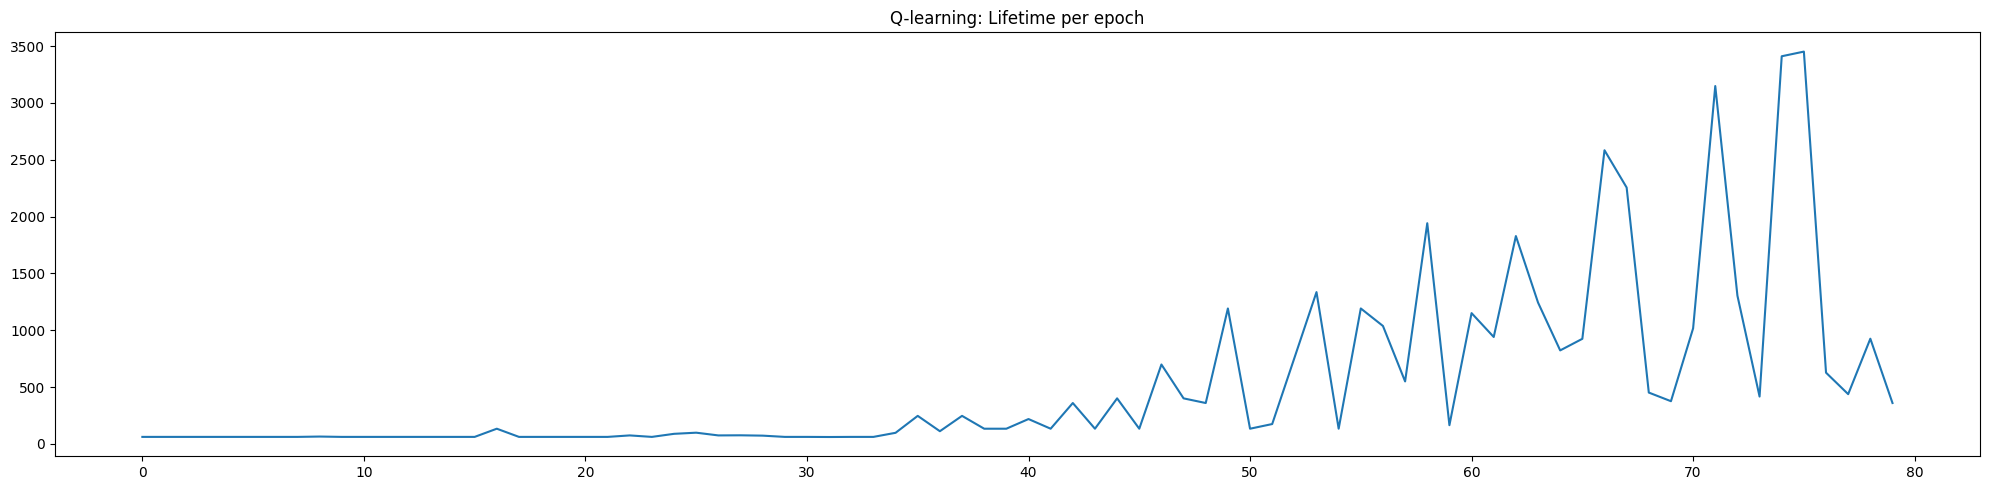

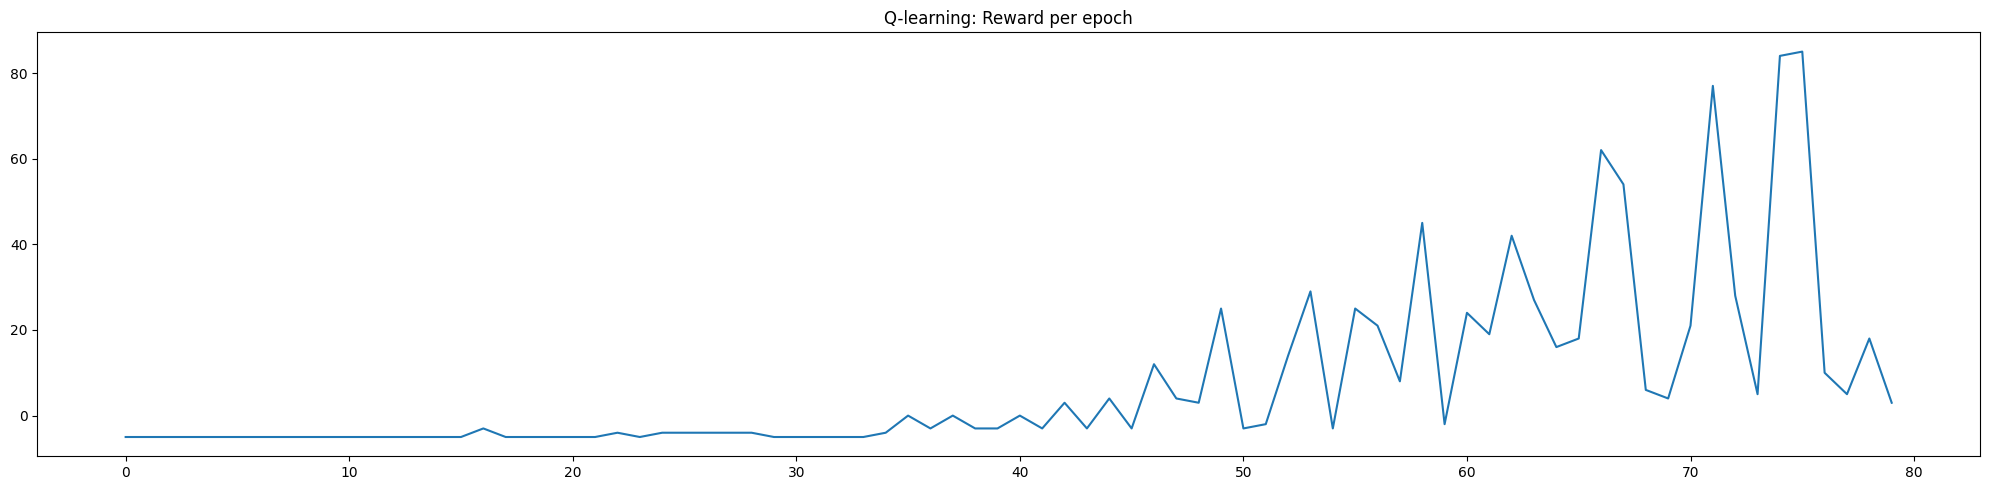

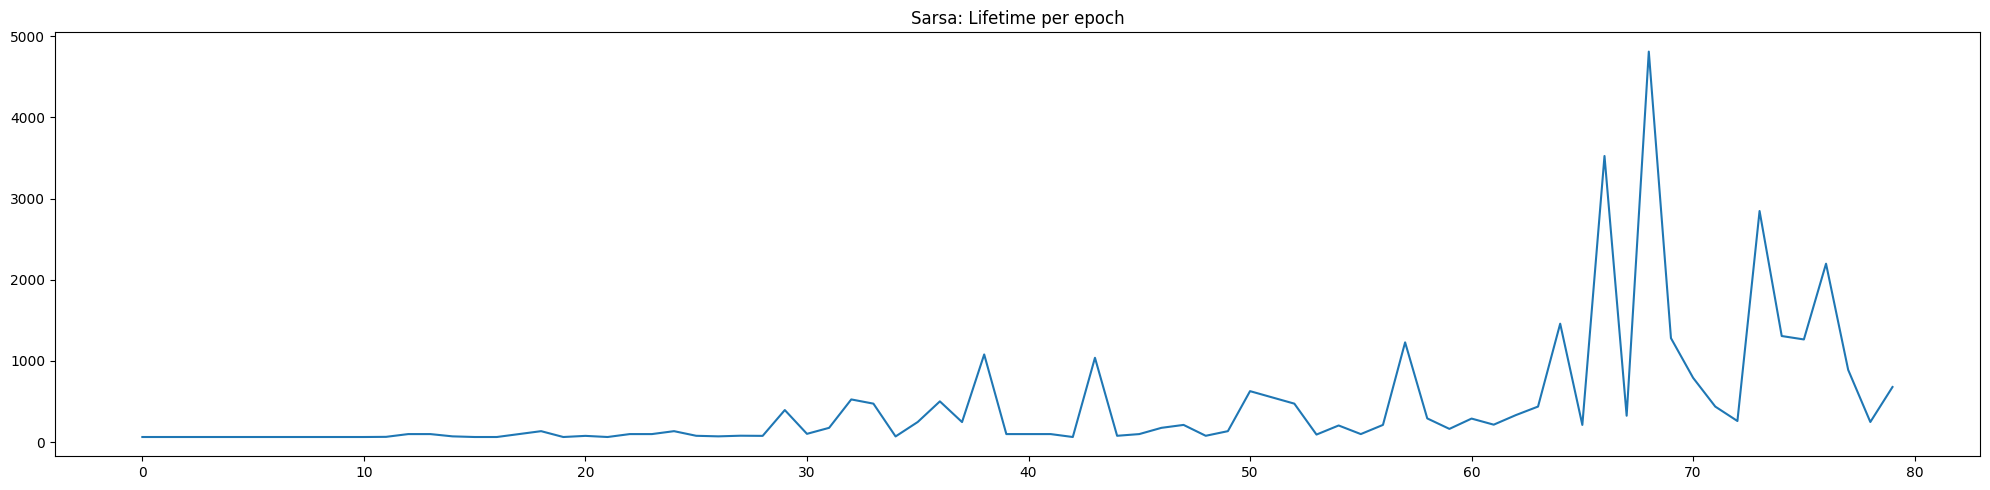

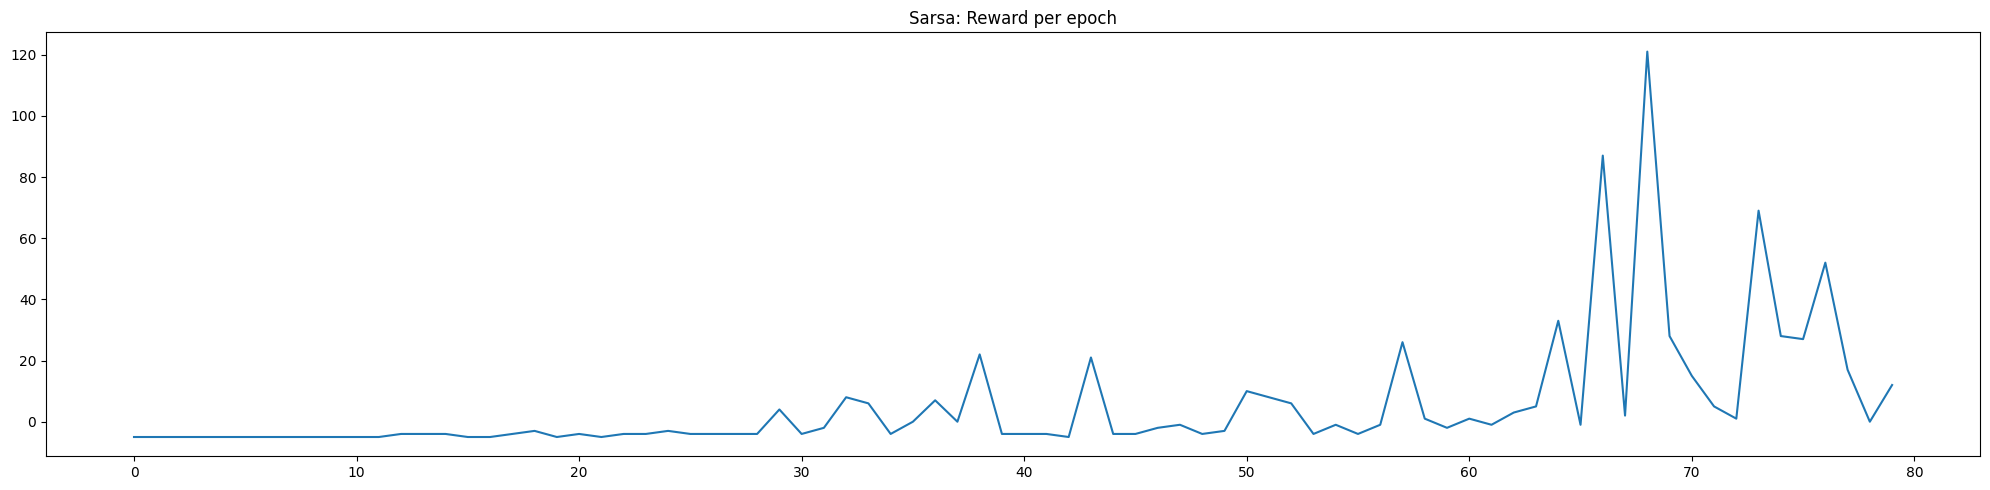

In [36]:
# plot Q-learning
plot_graph(lifetime_per_epoch, "Q-learning: Lifetime per epoch")
plot_graph(reward_per_epoch, "Q-learning: Reward per epoch")
# plot Sarsa
plot_graph(lifetime_per_epoch_sarsa, "Sarsa: Lifetime per epoch")
plot_graph(reward_per_epoch_sarsa, "Sarsa: Reward per epoch")